## **Proyecto**
### **Detector de reseñas falsas en plataformas de comercio electronico mediante distintos tipos de algoritmos**



#### Analítica Avanzada de Datos |@ IPN-ESCOM
Prof. **César Jesús Núñez Prado**

**Integrantes**:

*   Cortes Moreno Mauricio Hamabiel
*   Maldonado López Alejandro
*   Pacheco Molina Miguel Alejandro
*   Soria Martínez Jesús Armando





### 0° **Intro**



> Librerías

En la siguiente celda se importaron las librerías:

- **NumPy** para el manejo de arreglos multidimensionales y operaciones matemáticas de alto rendimiento.

- **Pandas** para la creación, manipulación y análisis de estructuras de datos como DataFrames y Series.

- **Kagglehub** para importar el conjunto de datos directamente desde Kaggle.

- **OS** para interactuar con el sistema operativo, por ejemplo, acceder a rutas de archivos o directorios.

- **Matplotlib** para generar visualizaciones como gráficas de líneas, barras, histogramas, etc.

- **Seaborn** una librería de visualización basada en Matplotlib que facilita la creación de gráficas estadísticas con un estilo más atractivo.

- **Scikit-learn** se llaman funciones como:
  - ***feature_extraction.text.TfidfVectorizer***: Para convertir texto en una matriz de características numéricas mediante TF-IDF.

  - ***model_selection.train_test_split***: Para dividir los datos en conjuntos de entrenamiento y prueba.

  - ***linear_model.HuberRegressor***: Modelo de regresión robusta que maneja valores atípicos.

  - ***metrics.classification_report***: Para generar un reporte con métricas de clasificación (precisión, recall, f1-score).

  - ***metrics.confusion_matrix***: Para construir la matriz de confusión en problemas de clasificación.

  - ***metrics.accuracy_score***: Para calcular la exactitud de un modelo.

- **re** Para buscar y manipular patrones de texto mediante expresiones regulares.

- **NLTK** una biblioteca de procesamiento de lenguaje natural con múltiples herramientas para análisis de texto.

- **corpus.stopwords**: Conjunto de palabras vacías que suelen eliminarse del texto por no aportar significado relevante.

- **stem.PorterStemmer**: Algoritmo de stemming para reducir palabras a su raíz o forma base.


In [ ]:
import numpy as np
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import HuberRegressor
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report, roc_curve, auc


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

#### Conjunto de datos en un **DataFrame**

> Se descarga el conjunto de datos en una ruta local

In [ ]:
path = kagglehub.dataset_download("mexwell/fake-reviews-dataset")
print("Ruta local:", path)

Using Colab cache for faster access to the 'fake-reviews-dataset' dataset.
Ruta local: /kaggle/input/fake-reviews-dataset


In [ ]:

print(os.listdir("/kaggle/input/fake-reviews-dataset"))

['fake reviews dataset.csv']


In [ ]:
df = pd.read_csv("/kaggle/input/fake-reviews-dataset/fake reviews dataset.csv")
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


#### 1° **Exploracion del Conjunto de Datos**

> Información general del conjunto de datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


> Verificación de Nulos

In [ ]:
df['text_'].isnull().sum()

np.int64(0)

In [ ]:
df['label'].isnull().sum()

np.int64(0)

In [ ]:
df['rating'].isnull().sum()

np.int64(0)

> Distribución de la variable rating (Calificación)

- Se cuenta con value_counts() y se ordena con sort_index() la cantidad de cada rating (calificación) de cada producto para explorar esta variable y si es factible caonsiderarla en la predición.

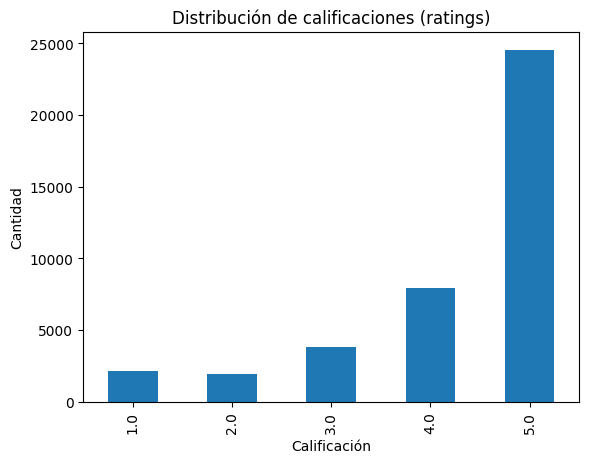

In [ ]:
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribución de calificaciones (ratings)")
plt.xlabel("Calificación")
plt.ylabel("Cantidad")
plt.show()

> Distribución de la etiqueta (label)

* Se verifica si cada etiqueta (label) tine la misma cantidad de registros y el conjutno de datos esta balanceado.  

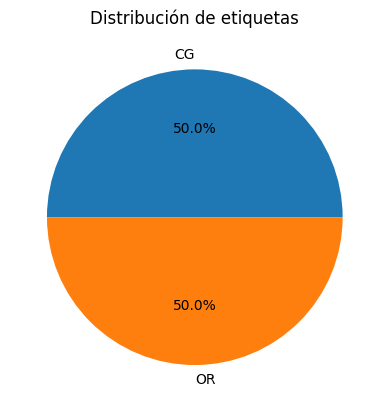

In [ ]:
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribución de etiquetas")
plt.ylabel("")
plt.show()

> Distribución de categorias

> Distribución del número de palabras








- En una nueva columna del conjunto de datos, utilizando apply() en conjunto de len() y split() se cuenta en cada reseña la cantidad de palabras en cada una.

In [ ]:
df["num_words"] = df["text_"].apply(lambda x: len(str(x).split()))

- Con ayuda de matplotlib se muestra la gráfica resultante.

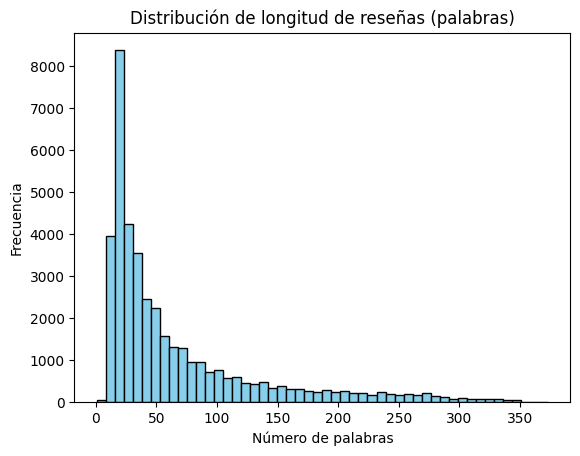

In [ ]:
plt.hist(df["num_words"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribución de longitud de reseñas (palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

> Verificación de las palabras más frecuentes

- En esta parte del código se toma en cuenta todo el conjutno de datos para mostrar que pelabras aparecen con mas frecuencia con ayuda de Counter() de la libreria collections, que ayuda con este conteo de palabras.

In [ ]:
all_words = " ".join(df['text_']).lower()
words = re.findall(r'\w+', all_words)

counter = Counter(words)
top_20 = counter.most_common(20)
print(top_20)

[('the', 157894), ('i', 112443), ('a', 97963), ('and', 87936), ('it', 82235), ('to', 68711), ('is', 64839), ('this', 50819), ('of', 45616), ('for', 39002), ('in', 29850), ('that', 27550), ('was', 26319), ('my', 25200), ('with', 23695), ('have', 23248), ('very', 21408), ('but', 20723), ('s', 19991), ('not', 19393)]


- Se muestra en una gráfica para una mejor visualización y asi justificar el uso de palabras vacias (stopword) en la limpieza.

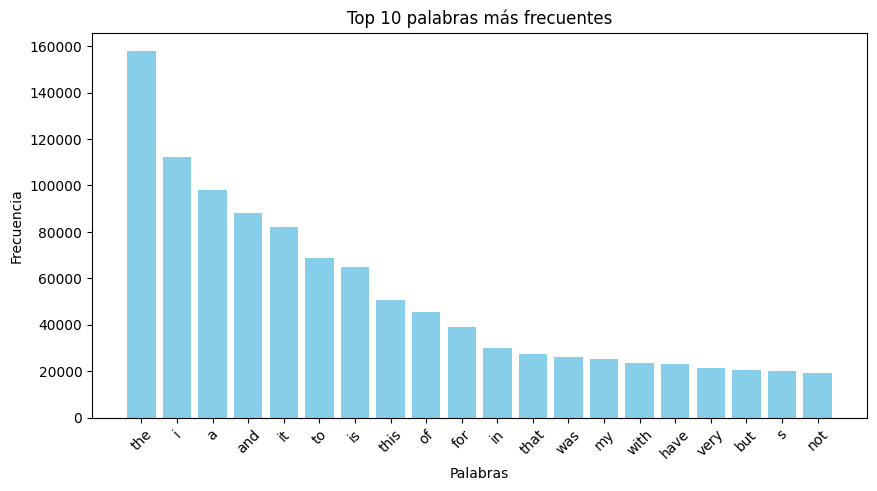

In [ ]:
palabras, frecuencias = zip(*top_20)

plt.figure(figsize=(10,5))
plt.bar(palabras, frecuencias, color="skyblue")
plt.title("Top 10 palabras más frecuentes")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

#### Relación entre "rating" y "label"

- Aqui se explora la distribución entre la etiqueta y la calificaión para ver si hay una relación en donde los comentarios por computadora eran tendian a ser sobre reseñas muy postivas o muy negativas, para tomarlo en cuenta en la predicción.

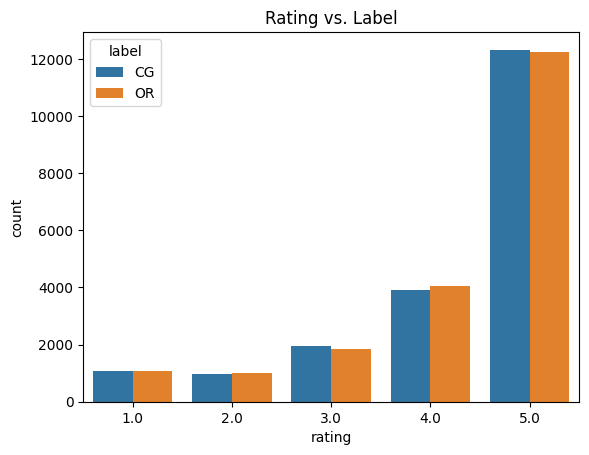

In [ ]:
sns.countplot(x="rating", hue="label", data=df)
plt.title("Rating vs. Label")
plt.show()

### Preprocesmaiento y limpieza

#### Filtrado de columnas

- Al solo ocupar dos columnas, "text_" que es la reseña y "label" que es la clasificacion, copiamos solo esas columnas en DataFrame

In [ ]:
df_ = df[["text_","label"]].copy()
df_

,text_,label
0,"Love this! Well made, sturdy, and very comfor...",CG
1,"love it, a great upgrade from the original. I...",CG
2,This pillow saved my back. I love the look and...,CG
3,"Missing information on how to use it, but it i...",CG
4,Very nice set. Good quality. We have had the s...,CG
...,...,...
40427,I had read some reviews saying that this bra r...,OR
40428,I wasn't sure exactly what it would be. It is ...,CG
40429,"You can wear the hood by itself, wear it with ...",OR
40430,I liked nothing about this dress. The only rea...,CG


#### Transformacion de los datos

- Se necesita que las etiquetas sean binarias, es por eso que CG = Computer-generated fake reviews y  OR = Original Reviews, la convertimos a 0 y 1 respectavamente.
- Con la funcion map, se hace esta convercion y si encuentra algo diferente lo clasifica como null

In [ ]:
print(df['label'].unique())

['CG' 'OR']


In [ ]:
df_['label_bin'] = df_['label'].map({'CG': 0, 'OR': 1})
df_

,text_,label,label_bin
0,"Love this! Well made, sturdy, and very comfor...",CG,0
1,"love it, a great upgrade from the original. I...",CG,0
2,This pillow saved my back. I love the look and...,CG,0
3,"Missing information on how to use it, but it i...",CG,0
4,Very nice set. Good quality. We have had the s...,CG,0
...,...,...,...
40427,I had read some reviews saying that this bra r...,OR,1
40428,I wasn't sure exactly what it would be. It is ...,CG,0
40429,"You can wear the hood by itself, wear it with ...",OR,1
40430,I liked nothing about this dress. The only rea...,CG,0


#### Limpieza de los datos

Antes de empezar con la limpieza es importante conocer las tecnicas de preprocesamiento en el procesamiento de lenguaje natural (PLN):


- Tokenizacion: es el primer paso en el preprocesamiento, donde se divide un texto en unidades más pequeñas llamadas tokens. Estos tokens pueden ser palabras, frases o incluso caracteres.

- Palabras vacias (stopwords): Las palabras vacías son palabras muy comunes que no aportan un significado relevante para el análisis de un texto, como los artículos ("el", "la"), preposiciones ("de", "con") y conjunciones ("y", "o").

En la siguiente celda se:
- Con ayuda de la libreria nltk se descarga la herramienta que ayudará a la eliminacion de palabras vacias (stopwords).
- Se declara en una función especificando que será en idioma ingles.
- Tambien se declará la funcion que nos ayudará a lematizar.

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
#lemmatizer = WordNetLemmatizer()
#stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


- Se declara una función que nos ayudara a normalizar el texto y a tokenizar, primero convertimos todo el texto a minusculas con lower(), despues se eliminan caracteres especiales, posteriormente se divide en tokens para aplica stopword, finalmente devuelve todo el conjunto del texto.

In [ ]:
def limpiar_texto_tfidf(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-z\s]', '', texto)
    tokens = texto.split()
    tokens = [word for word in tokens if word not in stop_words]
    ##tokens = [stemmer.stem(word) for word in tokens]
    ##tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

* Sedeclara una función extra para la limpieza para Glove, pues al ser una forma de vectorizacion diferente, se hace una limpieza menos "agresiva", ya que el modelo maneja mejor el ruido como las puntuaciones y stopwords.

In [ ]:
def limpiar_texto_glove(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+|www\S+", "", texto)         #eliminamos URLs
    texto = re.sub(r"[^a-z0-9\s.,!?']", " ", texto)      #conservamos puntuación ligera
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

- En esta celda se aplica la funcion en el texto y se guarda en una nueva columna

In [ ]:
df_['text_clean_tfidf'] = df_['text_'].apply(limpiar_texto_tfidf)
df_

,text_,label,label_bin,text_clean_tfidf
0,"Love this! Well made, sturdy, and very comfor...",CG,0,love well made sturdy comfortable love itvery ...
1,"love it, a great upgrade from the original. I...",CG,0,love great upgrade original ive mine couple years
2,This pillow saved my back. I love the look and...,CG,0,pillow saved back love look feel pillow
3,"Missing information on how to use it, but it i...",CG,0,missing information use great product price
4,Very nice set. Good quality. We have had the s...,CG,0,nice set good quality set two months
...,...,...,...,...
40427,I had read some reviews saying that this bra r...,OR,1,read reviews saying bra ran small ordered two ...
40428,I wasn't sure exactly what it would be. It is ...,CG,0,wasnt sure exactly would little large small si...
40429,"You can wear the hood by itself, wear it with ...",OR,1,wear hood wear hood wear jacket without hood s...
40430,I liked nothing about this dress. The only rea...,CG,0,liked nothing dress reason gave stars ordered ...


* En esta otra, la limpieza para embeddings se hace en una nueva columna

In [ ]:
df_['text_clean_glove'] = df_['text_'].apply(limpiar_texto_glove)
df_

,text_,label,label_bin,text_clean_tfidf,text_clean_glove
0,"Love this! Well made, sturdy, and very comfor...",CG,0,love well made sturdy comfortable love itvery ...,"love this! well made, sturdy, and very comfort..."
1,"love it, a great upgrade from the original. I...",CG,0,love great upgrade original ive mine couple years,"love it, a great upgrade from the original. i'..."
2,This pillow saved my back. I love the look and...,CG,0,pillow saved back love look feel pillow,this pillow saved my back. i love the look and...
3,"Missing information on how to use it, but it i...",CG,0,missing information use great product price,"missing information on how to use it, but it i..."
4,Very nice set. Good quality. We have had the s...,CG,0,nice set good quality set two months,very nice set. good quality. we have had the s...
...,...,...,...,...,...
40427,I had read some reviews saying that this bra r...,OR,1,read reviews saying bra ran small ordered two ...,i had read some reviews saying that this bra r...
40428,I wasn't sure exactly what it would be. It is ...,CG,0,wasnt sure exactly would little large small si...,i wasn't sure exactly what it would be. it is ...
40429,"You can wear the hood by itself, wear it with ...",OR,1,wear hood wear hood wear jacket without hood s...,"you can wear the hood by itself, wear it with ..."
40430,I liked nothing about this dress. The only rea...,CG,0,liked nothing dress reason gave stars ordered ...,i liked nothing about this dress. the only rea...


#### Representación vectorial

> TF-IDF

Se implementó **TF-IDF** como representación vectorial porque:  
- Reduce la influencia de palabras comunes que no aportan significado.  
- Resalta términos característicos de cada reseña.  
- Genera una representación numérica más informativa que la simple bolsa de palabras.

TF-IDF esta compuesto por:

**TF (Term Frequency)** – Frecuencia de término

El **TF** mide qué tan frecuente es una palabra en un documento.

$$
\mathrm{TF}(t,d) \;=\; \frac{\text{conteo}(t, d)}{\text{longitud}(d)}
$$

donde:
- conteo(t,d) = número de veces que aparece el término \(t\) en el documento \(d\).  
- longuitd(d) = número total de términos en el documento \(d\).



**IDF (Inverse Document Frequency)** – Frecuencia inversa de documento

El **IDF** mide qué tan rara es una palabra en el corpus (colección de documentos).  

$$
\mathrm{IDF}(t) \;=\; \log \left( \frac{N}{1 + n_t} \right)
$$

donde:  
- N = número total de documentos en el corpus  
- n_t = número de documentos que contienen el término \(t\)  

 Palabras muy comunes (ej. *the, is, and*) tienen IDF bajo.  
Palabras distintivas (ej. *scam, refund, bot*) tienen IDF alto.  

---

Lo que construye al **TF-IDF** QUE combina ambas medidas:  
$$
\mathrm{TF-IDF}(t,d) = \mathrm{TF}(t,d) \times \mathrm{IDF}(t)
$$

De esta forma:  
- Una palabra recibe un peso alto si es frecuente en un documento pero rara en el corpus.  
- Palabras comunes en todos los textos reciben un peso bajo.




- Con TfidfVectorizer se convierte el texto limpio en una matriz numérica lista para meterlo al modelo.

In [ ]:
vectorizer_simple = TfidfVectorizer()
X_tfidf_simple = vectorizer_simple.fit_transform(df_['text_clean_tfidf'])

print("Forma del TF-IDF:", X_tfidf_simple.shape)

Forma del TF-IDF: (40432, 48294)


Se empleó un modelo TF-IDF enriquecido (unigramas y bigramas) con suavizado logarítmico y filtrado de términos, lo que permite capturar patrones de contexto y estilo en las reseñas, además de reducir el ruido léxico.

In [ ]:
vectorizer_compuesto = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),          #incluye unigramas y bigramas
    max_df=0.9,                  #ignora términos que aparecen en >90% de docs
    min_df=2,                    #ignora términos raros que aparecen <2 veces
    sublinear_tf=True,           #usa log(1 + tf) -> reduce impacto de palabras repetidas
)

X_tfidf_compuesto = vectorizer_compuesto.fit_transform(df_['text_clean_tfidf'])
print("Forma del TF-IDF:", X_tfidf_compuesto.shape)

Forma del TF-IDF: (40432, 133452)


#### Embeddings (Glove)

GloVe (Global Vectors for Word Representation) es un modelo preentrenado que aprende representaciones densas de palabras (embeddings), donde cada palabra se representa como un vector continuo en un espacio semántico.

* Aqui se descarga los distintos embeddings de 4 dimensiones distintas

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2025-11-05 01:04:25--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-11-05 01:04:26--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-11-05 01:04:26--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

* Mediante una función cargamos Glove

In [ ]:
def cargar_glove(path):
    embeddings = {}
    with open(path, 'r', encoding='utf8') as f:
        for line in f:
            valores = line.split()
            palabra = valores[0]
            vector = np.asarray(valores[1:], dtype='float32')
            embeddings[palabra] = vector
    return embeddings

glove_path = "glove.6B.50d.txt"
embeddings_index = cargar_glove(glove_path)
print(f" {len(embeddings_index)} palabras cargadas.")

 400000 palabras cargadas.


* Se aplica Glove a la columna 'text_clean_glove' y guardamos en una matriz el resultado mediante una función

In [ ]:
def vectorizar_glove(texto, embeddings, dim):
    palabras = texto.split()
    vectores = [embeddings[p] for p in palabras if p in embeddings]
    if len(vectores) == 0:
        return np.zeros(dim)
    return np.mean(vectores, axis=0)

X_glove = np.vstack(df_['text_clean_glove'].apply(lambda x: vectorizar_glove(x, embeddings_index,50)))


* En esta celda se explora algunos vectores con las plabras

### Modelado

---



* Creamos un DataFrame para el reporte de comparación

In [ ]:
columnas = [ #Definimos las columnas del DataFrame

    'Modelo',
    'Division',      #
    'Accuracy',
    'F1',
    'Precision',
    'Recall'
]

df_comparativa = pd.DataFrame(columns=columnas)

In [ ]:
df_comparativa


,Modelo,Division,Accuracy,F1,Precision,Recall


* Al ser varios algoritmos, con varias formas de entrenamiento y distitntas formas de vectorización se decidió declarar una función.

In [ ]:
def modelado_entrenamiento(X, y, model, nombre_modelo, umbral = 0):
  divisiones = [0.1, 0.2, 0.3]
  for division in divisiones:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=division, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n------Division {(1-division)*100}% entrenamiento y {division*100:.0f}% prueba------\n")

    if umbral != 0:
            # Si el modelo tiene decision_function(), úsala
            if hasattr(model, "decision_function"):
                y_scores = model.decision_function(X_test)
            # Si no, intenta usar predict() como score continuo
            elif hasattr(model, "predict"):
                y_scores = model.predict(X_test)
            else:
                print("El modelo no tiene ni decision_function ni predict.")
                continue

            y_pred = (y_scores > umbral).astype(int)
    else:
        # Para clasificadores binarios normales
        y_scores = model.predict(X_test)
        if y_scores.ndim > 1:  # Si devuelve probabilidades
            y_scores = y_scores[:, 1]


    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    roc_auc = auc(*roc_curve(y_test, y_scores)[:2])

    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"AUC: {roc_auc:.4f}")

    df_comparativa.loc[len(df_comparativa)] = { #guardamos en el dataframe los resultados de cada division
            'Modelo': nombre_modelo,
            'Division': f"{int((1-division)*100)}/{int(division*100)}",
            'Accuracy': acc,
            'F1': f1,
            'Precision': prec,
            'Recall': rec
        }

    print("\nReporte de clasificación:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel('Predicción')
    plt.ylabel('Verdadero')
    plt.title('Matriz de Confusión')
    plt.show()


    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend()
    plt.show()

#### Regresion de Huber + TF-IDF simple

- Se definen las viarbles X & Y para la regresión de Huber.

In [ ]:
X_huber = X_tfidf_simple
y_huber = df_['label_bin']

> Prediciones y umbral

Huber al regresar valores continuos se define un umbral para hacer la clasificación:

* Si y_ped ≥ Umbral, el modelo predice **real** (1).
* Si y_pred < Umbral, el modelo predice **falsa** (0).




**Por ejemplo:**
Supongamos que tenemos los siguientes coeficientes:

| Palabra | Coeficiente $(\beta)$ | Interpretación |
| :--- | :--- | :--- |
| "buy" | -0.9 | Muy asociada a fake |
| "click" | -0.7 | Indicio de spam/fake |
| "excellent" | +0.8 | Asociada a reviews reales |
| "recommend" | +0.6 | También asociada a reales |

* Si un review contiene las palabras **"buy"** y **"click"**, el resultado de la suma de sus coeficientes será negativo, lo que hará que la probabilidad baje hacia **0** y sea más probable que se clasifique como **falsa**.
* Si un review contiene la palabra **"excellent"**, el resultado de la suma será positivo, lo que elevará la probabilidad hacia **1** y será más probable que se clasifique como **real**.

Supongamos que tenemos la siguiente reseña:

`"Excellent product, I recommend you to buy"`

> Tenemos que en la vectorización de TF-IDF:

* "excellent" → 0.5
* "recommend" → 0.4
* "buy" → 0.2
* "click" → 0.0 (no aparece)

> Multiplicamos por coeficientes

$$
\hat{y} = \beta_0 + (0.8 \times 0.5) + (0.6 \times 0.4) + (-0.9 \times 0.2) + (-0.7 \times 0.0)
$$

Supongamos que $\beta_0 = 0.3$:

$$
\hat{y} = 0.3 + 0.4 + 0.24 - 0.18 + 0
$$

$$
\hat{y} = 0.76
$$

> Paso 3: Aplicar umbral

* Como $0.76 \geq 0.5 \rightarrow$ el review se clasifica como **REAL (clase 1)**.

* Se aplica la función declarada anteriormente con la bandera de umbral activa para que haga la clasificación por medio del umbral.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.8830
F1 Score: 0.8853
Precision: 0.8821
Recall: 0.8885
AUC: 0.9548

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      1990
           1       0.88      0.89      0.89      2054

    accuracy                           0.88      4044
   macro avg       0.88      0.88      0.88      4044
weighted avg       0.88      0.88      0.88      4044



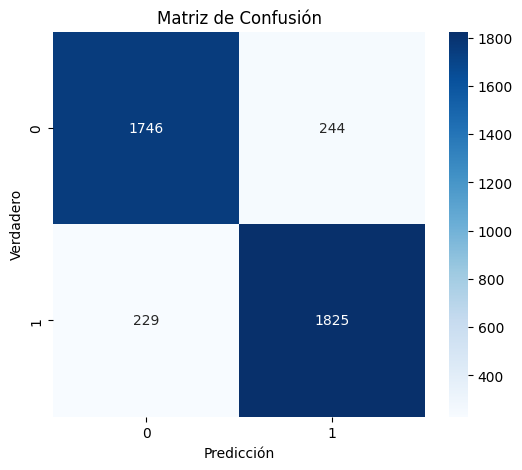

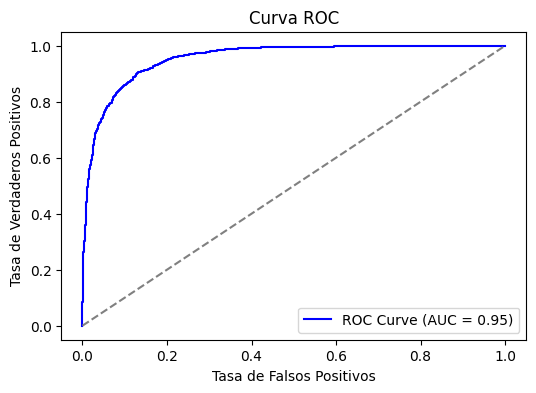

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.8751
F1 Score: 0.8768
Precision: 0.8710
Recall: 0.8826
AUC: 0.9498

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4016
           1       0.87      0.88      0.88      4071

    accuracy                           0.88      8087
   macro avg       0.88      0.88      0.88      8087
weighted avg       0.88      0.88      0.88      8087



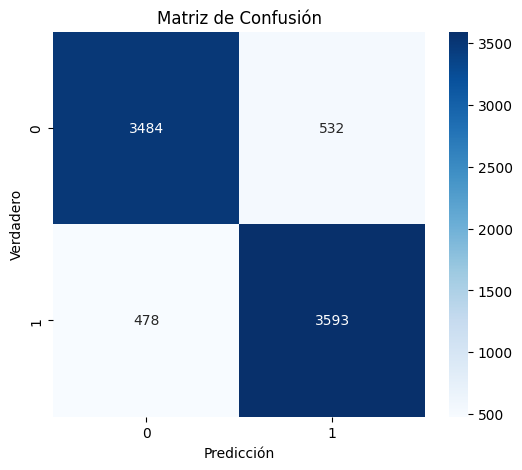

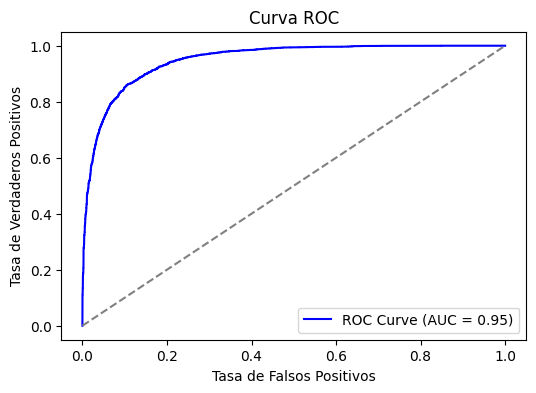

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.8768
F1 Score: 0.8771
Precision: 0.8748
Recall: 0.8795
AUC: 0.9477

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88      6066
           1       0.87      0.88      0.88      6064

    accuracy                           0.88     12130
   macro avg       0.88      0.88      0.88     12130
weighted avg       0.88      0.88      0.88     12130



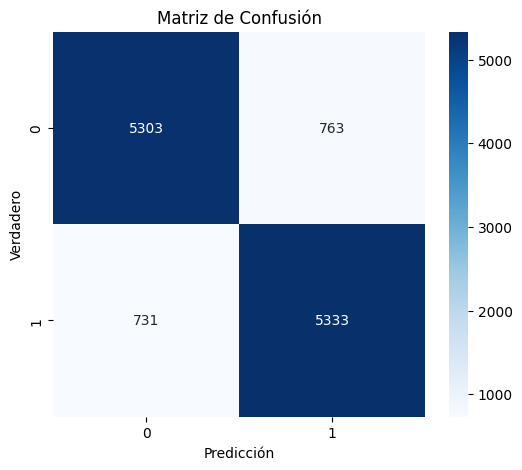

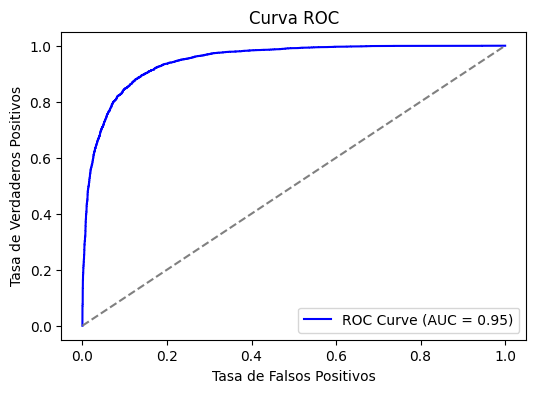

In [ ]:
huber = HuberRegressor()
modelado_entrenamiento(X_huber, y_huber, huber, 'Huber + TF-IDF simple', umbral = 0.5)

#### Huber + TF-IDF compuesto con unigramas y bigramas

* Se declara las variables ahora con el TF-IDF que es con unigramas y bigramas

In [ ]:
X_huber = X_tfidf_compuesto
y_huber = df_['label_bin']

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.9236
F1 Score: 0.9262
Precision: 0.9090
Recall: 0.9440
AUC: 0.9744

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      1990
           1       0.91      0.94      0.93      2054

    accuracy                           0.92      4044
   macro avg       0.92      0.92      0.92      4044
weighted avg       0.92      0.92      0.92      4044



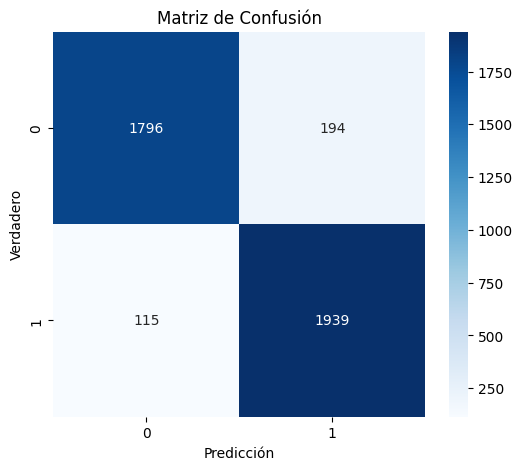

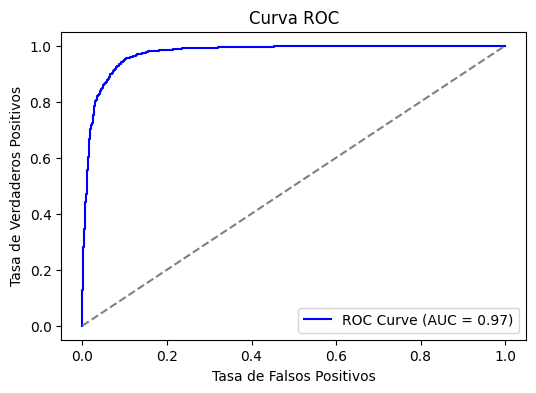

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.9211
F1 Score: 0.9237
Precision: 0.8997
Recall: 0.9492
AUC: 0.9745

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      4016
           1       0.90      0.95      0.92      4071

    accuracy                           0.92      8087
   macro avg       0.92      0.92      0.92      8087
weighted avg       0.92      0.92      0.92      8087



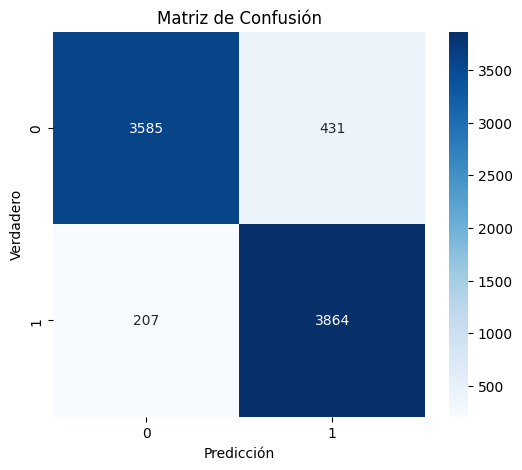

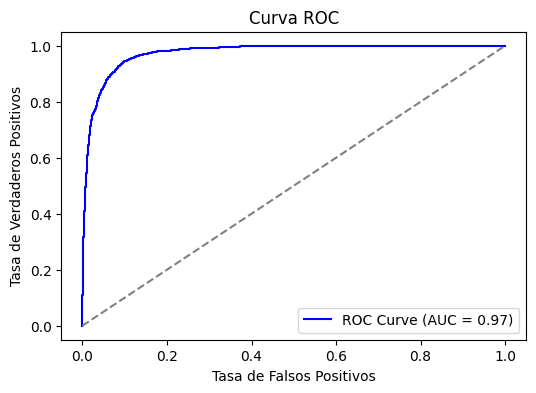

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.9183
F1 Score: 0.9203
Precision: 0.8981
Recall: 0.9436
AUC: 0.9736

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      6066
           1       0.90      0.94      0.92      6064

    accuracy                           0.92     12130
   macro avg       0.92      0.92      0.92     12130
weighted avg       0.92      0.92      0.92     12130



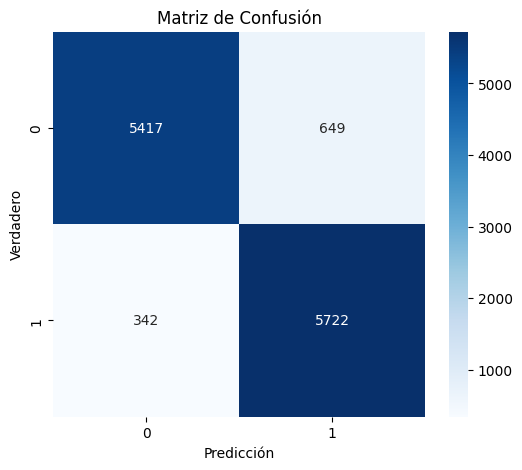

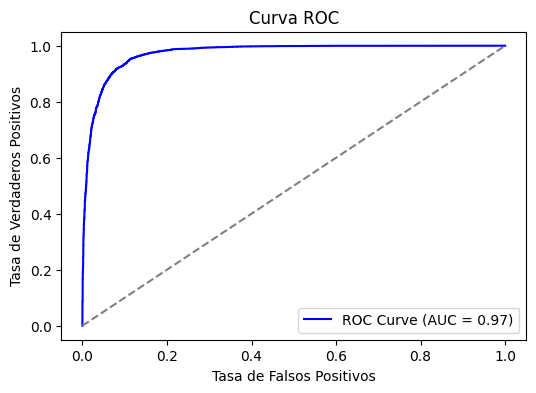

In [ ]:
modelado_entrenamiento(X_huber, y_huber, huber, 'Huber + TF-IDF compuesto', umbral=0.5)

In [ ]:
df_comparativa

,Modelo,Division,Accuracy,F1,Precision,Recall
0,Huber + TF-IDF simple,90/10,0.883037,0.885278,0.882069,0.888510
1,Huber + TF-IDF simple,80/20,0.875108,0.876769,0.871030,0.882584
2,Huber + TF-IDF simple,70/30,0.876834,0.877138,0.874836,0.879453
3,Huber + TF-IDF compuesto,90/10,0.923591,0.926200,0.909048,0.944012
4,Huber + TF-IDF compuesto,80/20,0.921108,0.923739,0.899651,0.949153
5,Huber + TF-IDF compuesto,70/30,0.918302,0.920306,0.898132,0.943602


#### Naive Bayes + TF-IDF simple

* Se declara las variables X & Y para entrenar el modelo Naive Bayes

In [ ]:
X_nb = X_tfidf_simple
y_nb = df_['label_bin']

* Se llama al modelo y se declara en la función para su entrenamiento y evaluación


------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.8541
F1 Score: 0.8475
Precision: 0.9031
Recall: 0.7984
AUC: 0.8550

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      1990
           1       0.90      0.80      0.85      2054

    accuracy                           0.85      4044
   macro avg       0.86      0.85      0.85      4044
weighted avg       0.86      0.85      0.85      4044



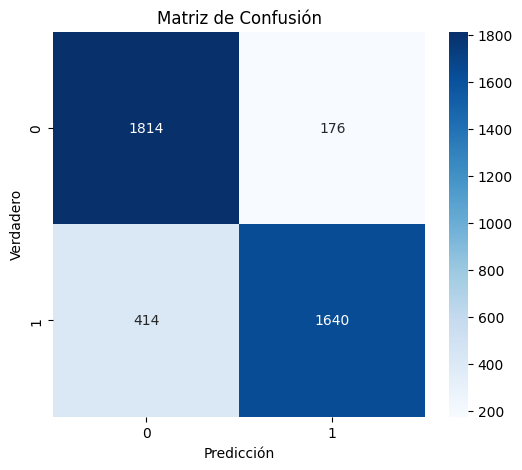

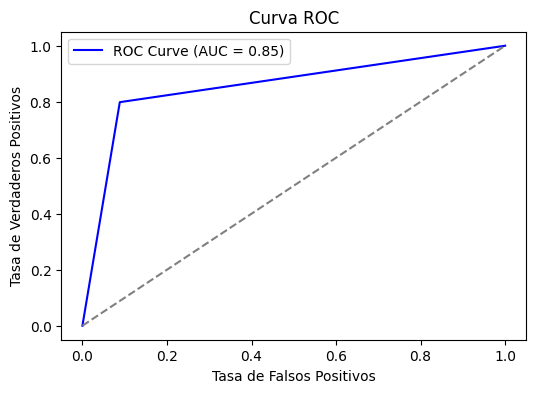


------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.8564
F1 Score: 0.8496
Precision: 0.8986
Recall: 0.8057
AUC: 0.8568

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      4016
           1       0.90      0.81      0.85      4071

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087



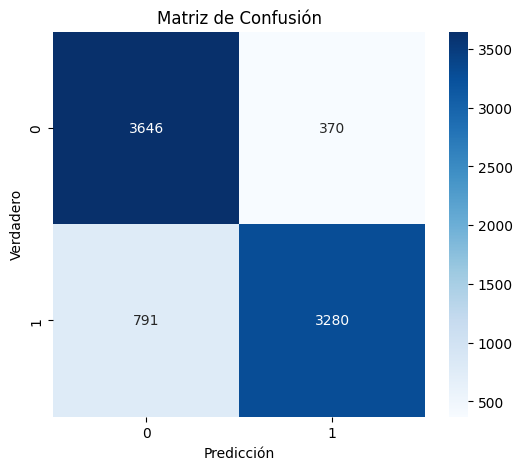

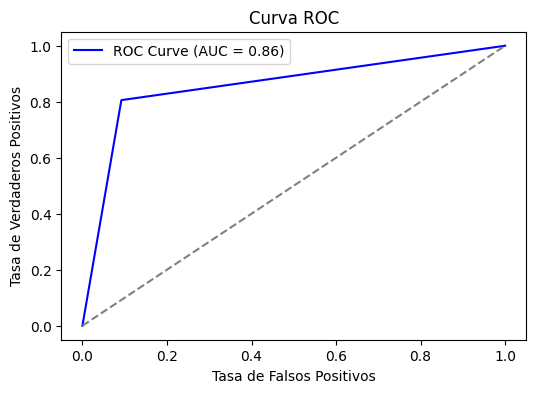


------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.8572
F1 Score: 0.8499
Precision: 0.8958
Recall: 0.8084
AUC: 0.8572

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.91      0.86      6066
           1       0.90      0.81      0.85      6064

    accuracy                           0.86     12130
   macro avg       0.86      0.86      0.86     12130
weighted avg       0.86      0.86      0.86     12130



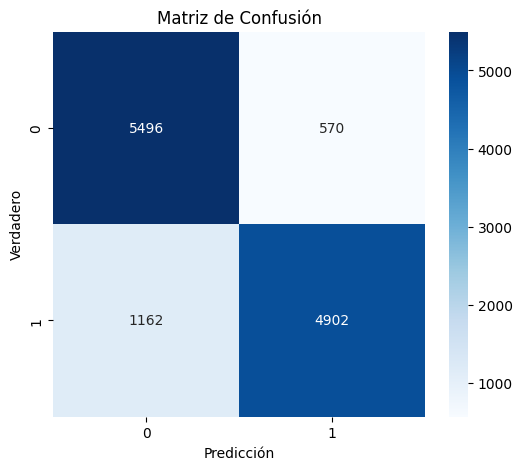

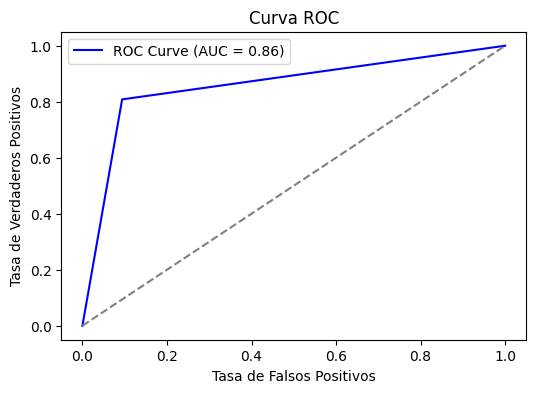

In [ ]:
model_nb = MultinomialNB()
modelado_entrenamiento(X_nb, y_nb, model_nb, 'Naive Bayes + TF-IDF simple')

#### Naive Bayes + TF-IDF compuesto

* Se declara las variables con el TF-IDF para unigramas y bigramas

In [ ]:
X_nb = X_tfidf_compuesto
y_nb = df_['label_bin']


------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.8981
F1 Score: 0.8984
Precision: 0.9101
Recall: 0.8870
AUC: 0.8983

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1990
           1       0.91      0.89      0.90      2054

    accuracy                           0.90      4044
   macro avg       0.90      0.90      0.90      4044
weighted avg       0.90      0.90      0.90      4044



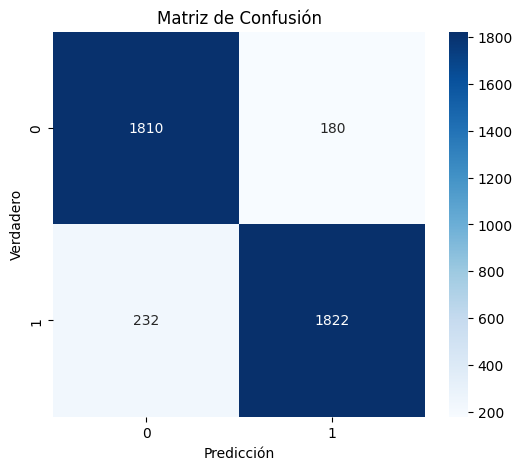

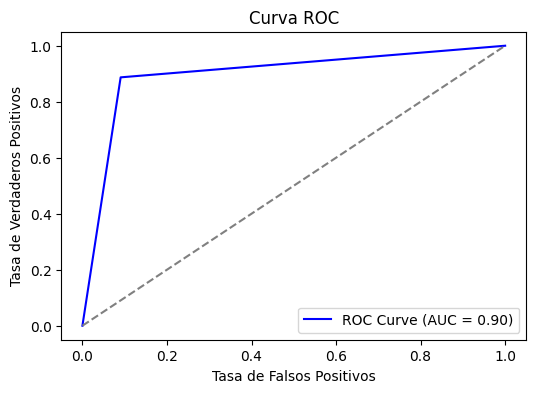


------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.9013
F1 Score: 0.9014
Precision: 0.9066
Recall: 0.8963
AUC: 0.9014

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      4016
           1       0.91      0.90      0.90      4071

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087



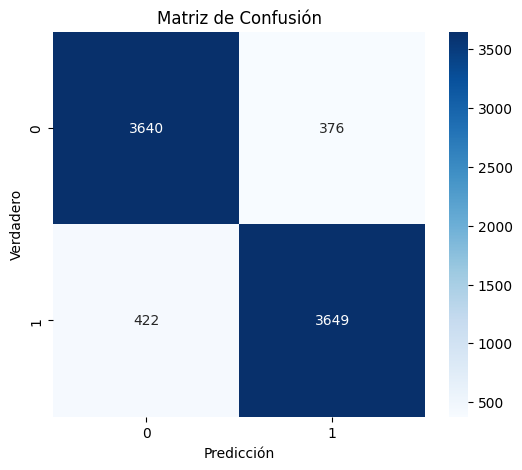

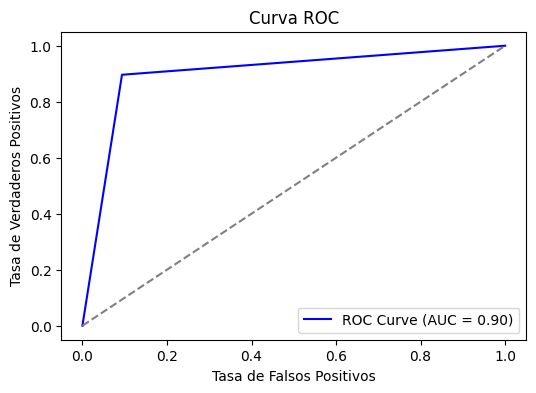


------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.8993
F1 Score: 0.8987
Precision: 0.9036
Recall: 0.8938
AUC: 0.8993

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      6066
           1       0.90      0.89      0.90      6064

    accuracy                           0.90     12130
   macro avg       0.90      0.90      0.90     12130
weighted avg       0.90      0.90      0.90     12130



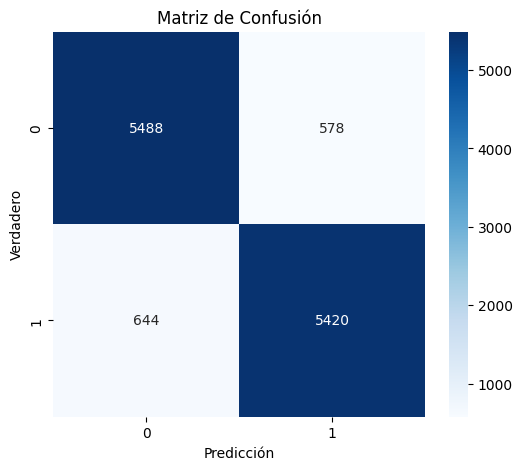

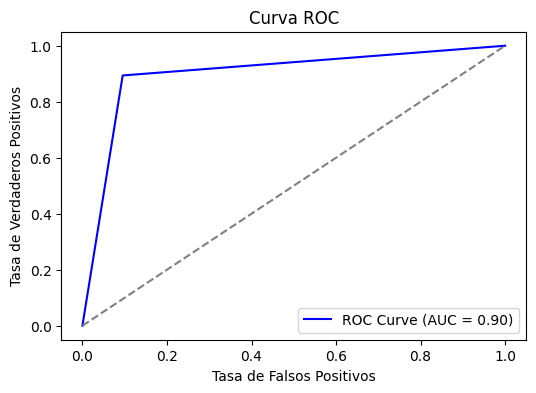

In [ ]:
modelado_entrenamiento(X_nb, y_nb, model_nb, 'Naive Bayes + TF-IDF compuesto')

In [ ]:
df_comparativa

,Modelo,Division,Accuracy,F1,Precision,Recall
0,Huber + TF-IDF simple,90/10,0.883037,0.885278,0.882069,0.888510
1,Huber + TF-IDF simple,80/20,0.875108,0.876769,0.871030,0.882584
2,Huber + TF-IDF simple,70/30,0.876834,0.877138,0.874836,0.879453
3,Huber + TF-IDF compuesto,90/10,0.923591,0.926200,0.909048,0.944012
4,Huber + TF-IDF compuesto,80/20,0.921108,0.923739,0.899651,0.949153
5,Huber + TF-IDF compuesto,70/30,0.918302,0.920306,0.898132,0.943602
6,Naive Bayes + TF-IDF,90/10,0.854105,0.847545,0.903084,0.798442
7,Naive Bayes + TF-IDF,80/20,0.856436,0.849631,0.898630,0.805699
8,Naive Bayes + TF-IDF,70/30,0.857214,0.849861,0.895833,0.808377
9,Naive Bayes + TF-IDF compuesto,90/10,0.898121,0.898422,0.910090,0.887050


* Se prueba Naive Bayes con un modelo de Bernulli

#### SVM + TF-IDF

In [ ]:
X_svm = X_tfidf_compuesto
y_svm = df_['label_bin']


------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.9214
F1 Score: 0.9233
Precision: 0.9153
Recall: 0.9314
AUC: 0.9212

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      1990
           1       0.92      0.93      0.92      2054

    accuracy                           0.92      4044
   macro avg       0.92      0.92      0.92      4044
weighted avg       0.92      0.92      0.92      4044



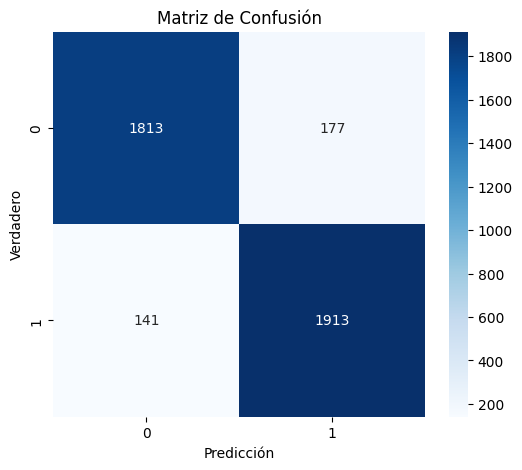

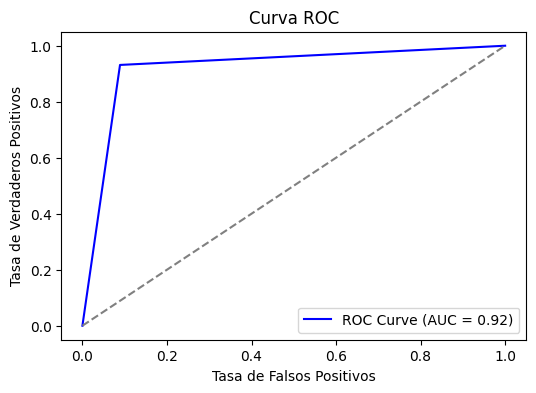


------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.9225
F1 Score: 0.9244
Precision: 0.9077
Recall: 0.9418
AUC: 0.9223

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      4016
           1       0.91      0.94      0.92      4071

    accuracy                           0.92      8087
   macro avg       0.92      0.92      0.92      8087
weighted avg       0.92      0.92      0.92      8087



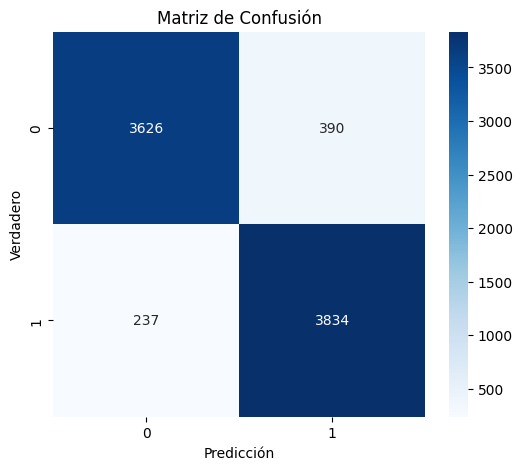

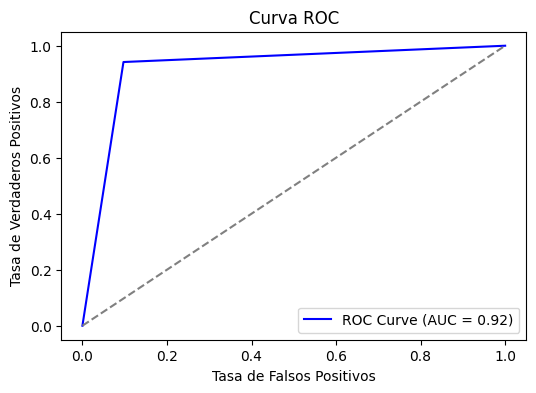


------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.9192
F1 Score: 0.9206
Precision: 0.9052
Recall: 0.9365
AUC: 0.9192

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      6066
           1       0.91      0.94      0.92      6064

    accuracy                           0.92     12130
   macro avg       0.92      0.92      0.92     12130
weighted avg       0.92      0.92      0.92     12130



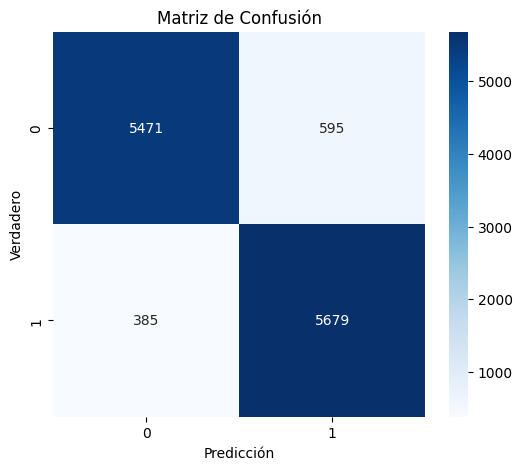

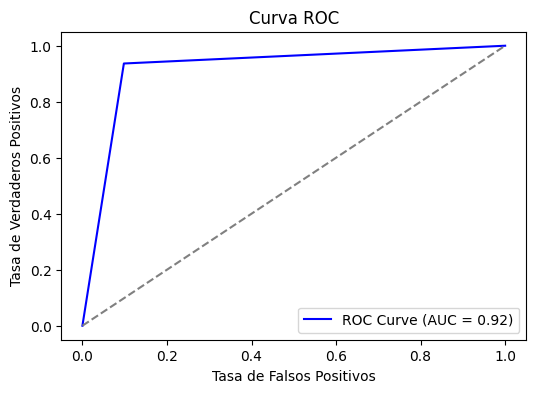

In [ ]:
modelo_svm = SVC(kernel='linear', probability=True, random_state=42)
modelado_entrenamiento(X_svm, y_svm, modelo_svm, 'SVM + TF-IDF compuesto')

In [ ]:
df_comparativa

,Modelo,Division,Accuracy,F1,Precision,Recall
0,Huber + TF-IDF simple,90/10,0.883037,0.885278,0.882069,0.888510
1,Huber + TF-IDF simple,80/20,0.875108,0.876769,0.871030,0.882584
2,Huber + TF-IDF simple,70/30,0.876834,0.877138,0.874836,0.879453
3,Huber + TF-IDF compuesto,90/10,0.923591,0.926200,0.909048,0.944012
4,Huber + TF-IDF compuesto,80/20,0.921108,0.923739,0.899651,0.949153
5,Huber + TF-IDF compuesto,70/30,0.918302,0.920306,0.898132,0.943602
6,Naive Bayes + TF-IDF,90/10,0.854105,0.847545,0.903084,0.798442
7,Naive Bayes + TF-IDF,80/20,0.856436,0.849631,0.898630,0.805699
8,Naive Bayes + TF-IDF,70/30,0.857214,0.849861,0.895833,0.808377
9,Naive Bayes + TF-IDF compuesto,90/10,0.898121,0.898422,0.910090,0.887050


#### SVM + Glove

* Primero se declaran las variables X & Y

In [ ]:
X_svm = X_glove
y_svm = df_['label_bin']


------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.8207
F1 Score: 0.8202
Precision: 0.8358
Recall: 0.8053
AUC: 0.8210

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82      1990
           1       0.84      0.81      0.82      2054

    accuracy                           0.82      4044
   macro avg       0.82      0.82      0.82      4044
weighted avg       0.82      0.82      0.82      4044



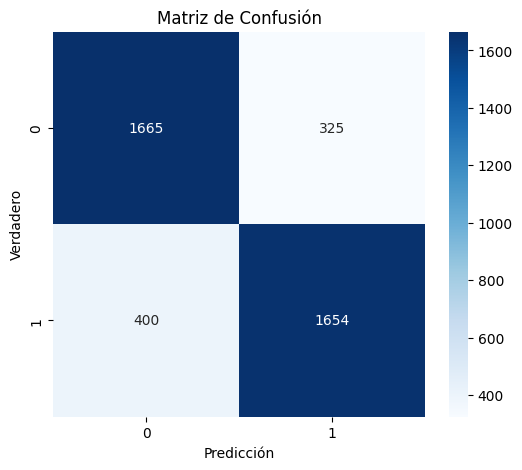

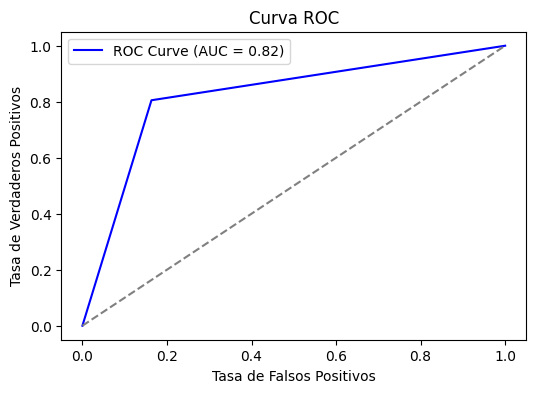


------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.8159
F1 Score: 0.8144
Precision: 0.8268
Recall: 0.8023
AUC: 0.8160

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      4016
           1       0.83      0.80      0.81      4071

    accuracy                           0.82      8087
   macro avg       0.82      0.82      0.82      8087
weighted avg       0.82      0.82      0.82      8087



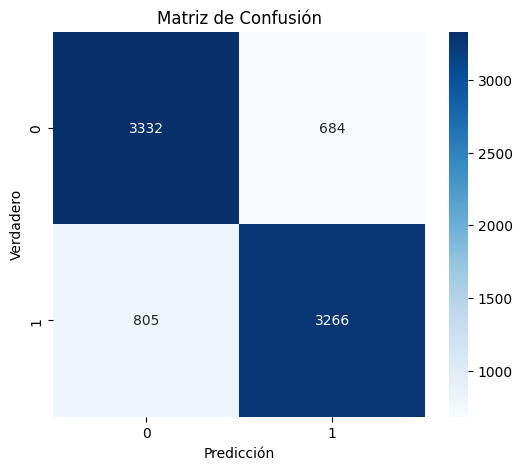

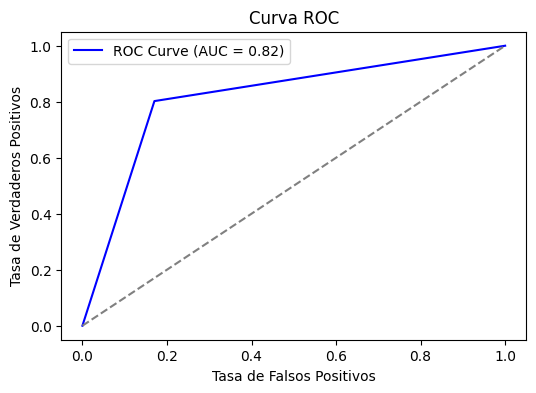


------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.8181
F1 Score: 0.8159
Precision: 0.8258
Recall: 0.8062
AUC: 0.8181

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      6066
           1       0.83      0.81      0.82      6064

    accuracy                           0.82     12130
   macro avg       0.82      0.82      0.82     12130
weighted avg       0.82      0.82      0.82     12130



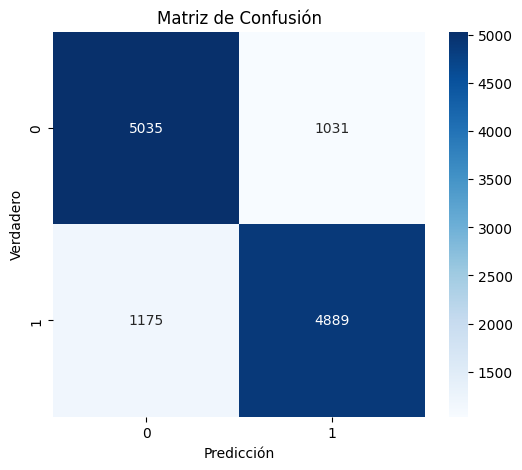

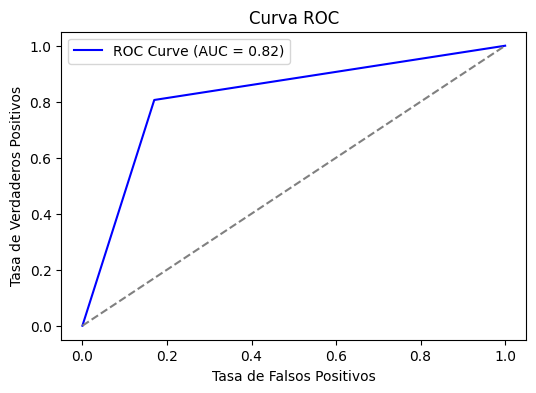

In [ ]:
modelo_svm = SVC(kernel='linear', random_state=7)
modelado_entrenamiento(X_svm, y_svm, modelo_svm, 'SVM + Glove')

In [ ]:
df_comparativa

,Modelo,Division,Accuracy,F1,Precision,Recall
0,SVM + Glove,90/10,0.822948,0.820910,0.844136,0.798929
1,SVM + Glove,80/20,0.818227,0.815697,0.833035,0.799067
2,SVM + Glove,70/30,0.818961,0.816142,0.828912,0.803760
3,SVM + Glove,90/10,0.820722,0.820233,0.835776,0.805258
4,SVM + Glove,80/20,0.815877,0.814362,0.826835,0.802260
5,SVM + Glove,70/30,0.818137,0.815921,0.825845,0.806234
6,SVM + Glove,90/10,0.820722,0.820233,0.835776,0.805258
7,SVM + Glove,80/20,0.815877,0.814362,0.826835,0.802260
8,SVM + Glove,70/30,0.818137,0.815921,0.825845,0.806234


#### Perceptrón Multicapa + Glove

In [ ]:
X_mlp = X_glove
y_mlp = df_['label_bin']

logistic + lbfgs

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.8393
F1 Score: 0.8381
Precision: 0.8578
Recall: 0.8194
AUC: 0.8396

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1990
           1       0.86      0.82      0.84      2054

    accuracy                           0.84      4044
   macro avg       0.84      0.84      0.84      4044
weighted avg       0.84      0.84      0.84      4044



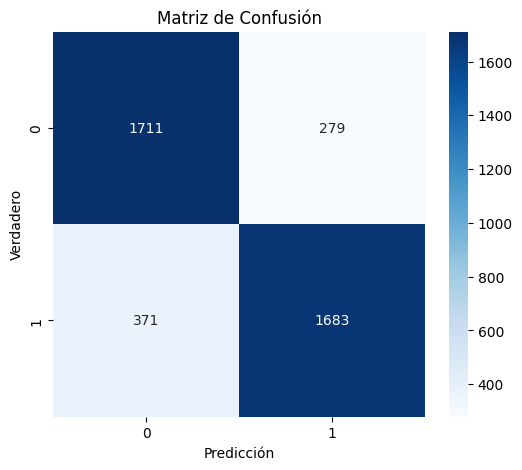

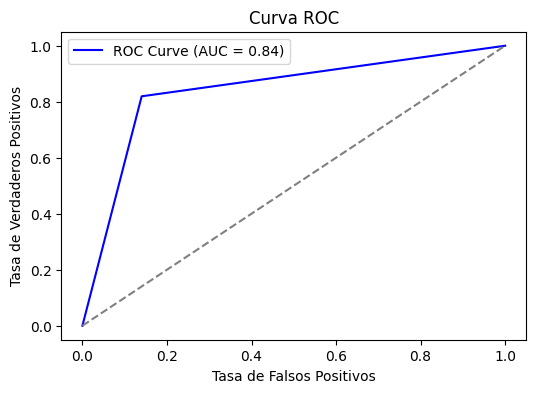

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.8348
F1 Score: 0.8334
Precision: 0.8463
Recall: 0.8209
AUC: 0.8349

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84      4016
           1       0.85      0.82      0.83      4071

    accuracy                           0.83      8087
   macro avg       0.84      0.83      0.83      8087
weighted avg       0.84      0.83      0.83      8087



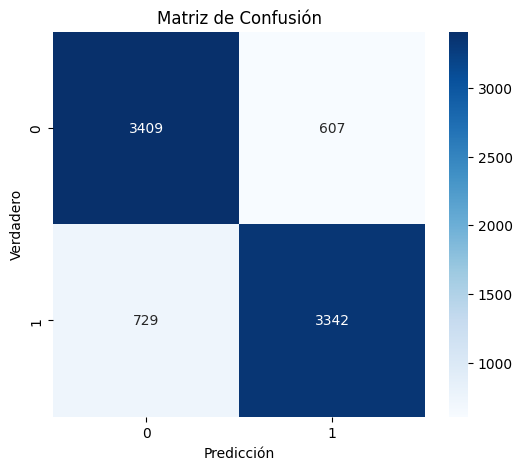

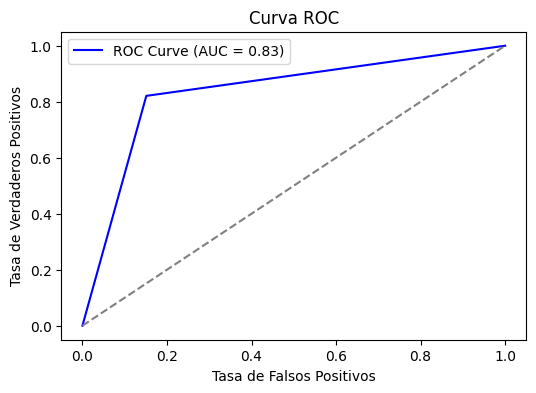

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.8354
F1 Score: 0.8337
Precision: 0.8425
Recall: 0.8250
AUC: 0.8354

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      6066
           1       0.84      0.83      0.83      6064

    accuracy                           0.84     12130
   macro avg       0.84      0.84      0.84     12130
weighted avg       0.84      0.84      0.84     12130



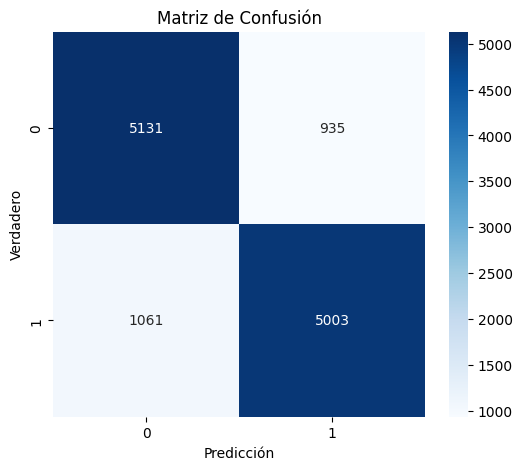

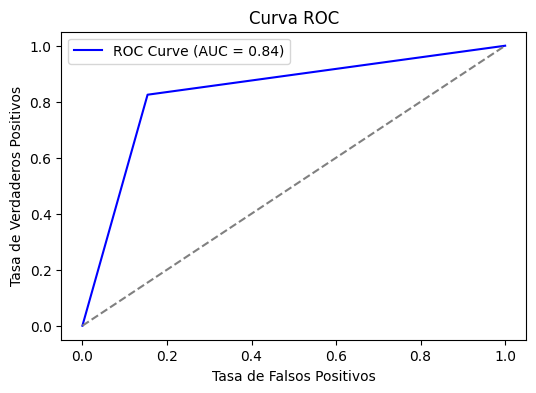

In [ ]:
modelo_mlp = MLPClassifier(hidden_layer_sizes=(30,15), activation= 'logistic', solver='lbfgs', max_iter=500, random_state=7)
modelado_entrenamiento(X_mlp, y_mlp, modelo_mlp, 'Perceptrón Multicapa (logistic - lbfgs) + Glove')

#### tanh + sgd

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.8291
F1 Score: 0.8272
Precision: 0.8504
Recall: 0.8053
AUC: 0.8295

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1990
           1       0.85      0.81      0.83      2054

    accuracy                           0.83      4044
   macro avg       0.83      0.83      0.83      4044
weighted avg       0.83      0.83      0.83      4044



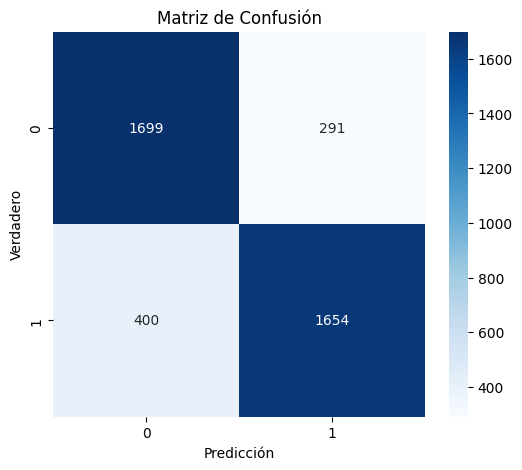

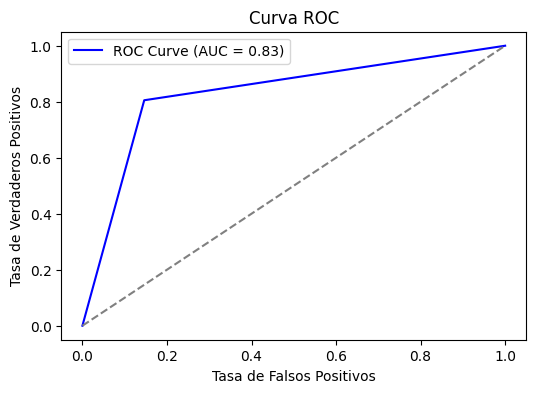

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.8270
F1 Score: 0.8253
Precision: 0.8393
Recall: 0.8118
AUC: 0.8271

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      4016
           1       0.84      0.81      0.83      4071

    accuracy                           0.83      8087
   macro avg       0.83      0.83      0.83      8087
weighted avg       0.83      0.83      0.83      8087



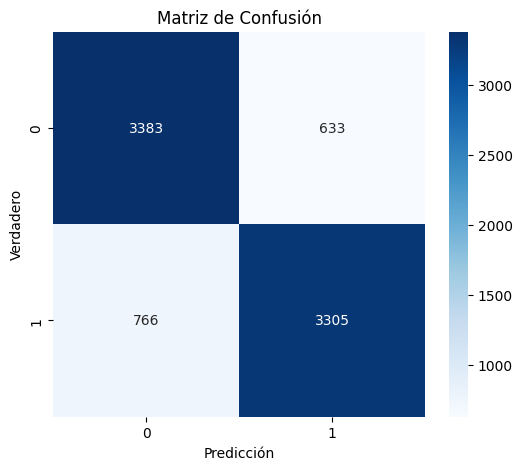

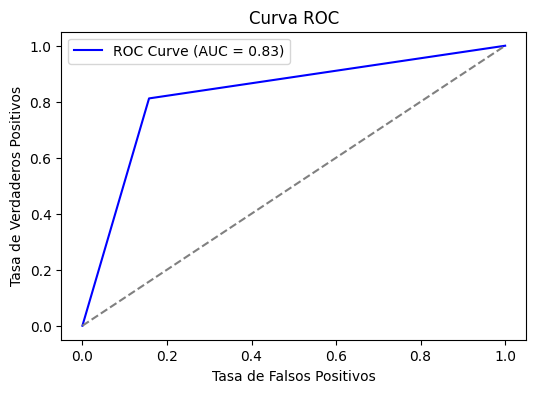

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(



------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.8270
F1 Score: 0.8242
Precision: 0.8379
Recall: 0.8109
AUC: 0.8270

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      6066
           1       0.84      0.81      0.82      6064

    accuracy                           0.83     12130
   macro avg       0.83      0.83      0.83     12130
weighted avg       0.83      0.83      0.83     12130



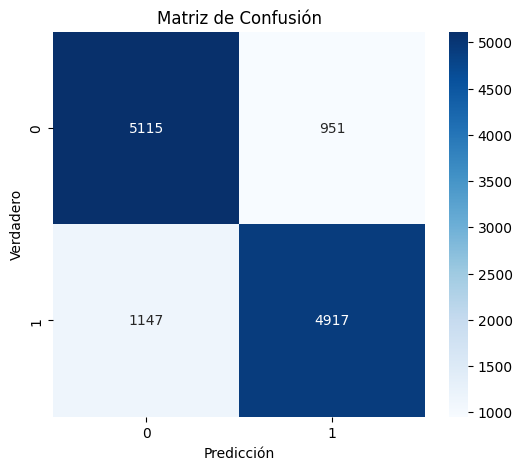

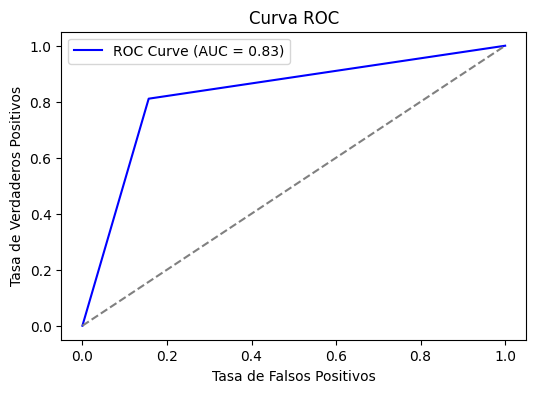

In [ ]:
modelo_mlp = MLPClassifier(hidden_layer_sizes=(30,15), activation= 'tanh', solver='sgd', max_iter=500, random_state=7)
modelado_entrenamiento(X_mlp, y_mlp, modelo_mlp, 'Perceptrón Multicapa (tanh - sgd) + Glove')


##### relu + lbfgs


------Division 90.0% entrenamiento y 10% prueba------

Accuracy: 0.8217
F1 Score: 0.8219
Precision: 0.8341
Recall: 0.8101
AUC: 0.8219

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1990
           1       0.83      0.81      0.82      2054

    accuracy                           0.82      4044
   macro avg       0.82      0.82      0.82      4044
weighted avg       0.82      0.82      0.82      4044



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


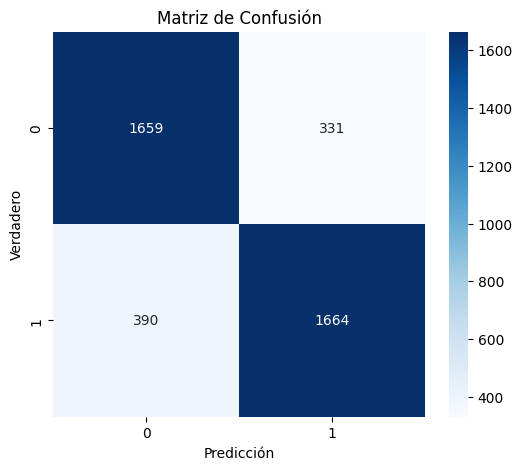

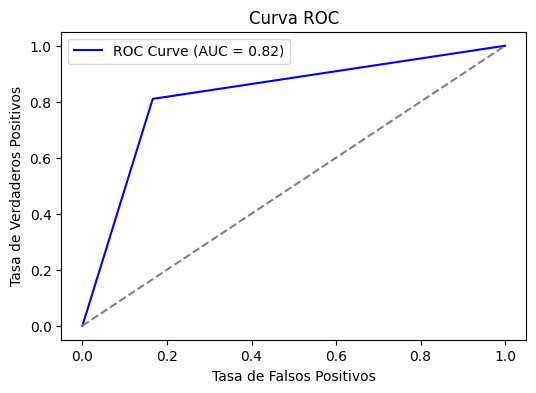

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 80.0% entrenamiento y 20% prueba------

Accuracy: 0.8226
F1 Score: 0.8219
Precision: 0.8305
Recall: 0.8136
AUC: 0.8226

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      4016
           1       0.83      0.81      0.82      4071

    accuracy                           0.82      8087
   macro avg       0.82      0.82      0.82      8087
weighted avg       0.82      0.82      0.82      8087



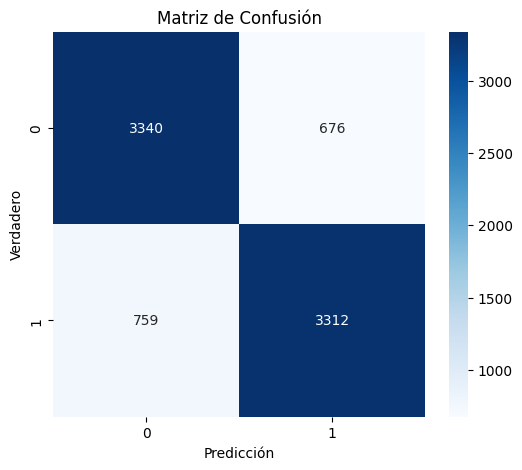

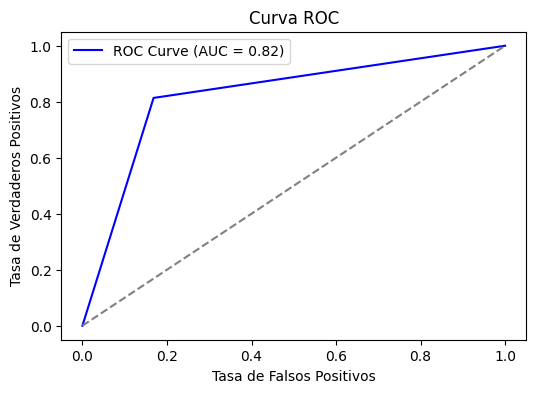

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)



------Division 70.0% entrenamiento y 30% prueba------

Accuracy: 0.8208
F1 Score: 0.8185
Precision: 0.8289
Recall: 0.8084
AUC: 0.8208

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      6066
           1       0.83      0.81      0.82      6064

    accuracy                           0.82     12130
   macro avg       0.82      0.82      0.82     12130
weighted avg       0.82      0.82      0.82     12130



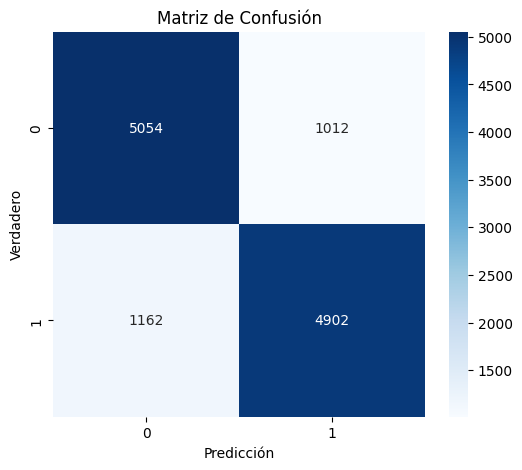

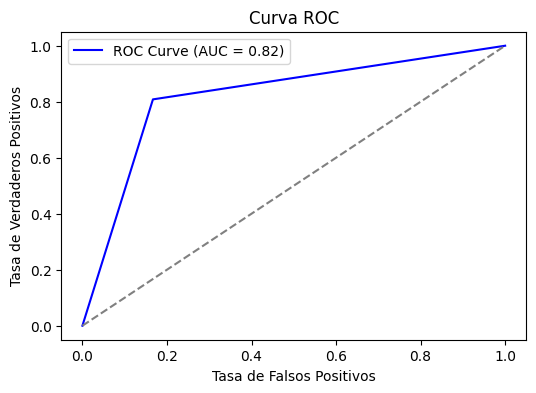

In [ ]:
modelo_mlp = MLPClassifier(hidden_layer_sizes=(30,15), activation= 'relu', solver='lbfgs', max_iter=500, random_state=7)
modelado_entrenamiento(X_mlp, y_mlp, modelo_mlp, 'Perceptrón Multicapa (relu - lbfgs) + Glove')

* Despues de hacer las combinaciones necesarias para obtener la función de activacion adecuada y 'solver', se obtuvieron los siguientes resultados:

In [ ]:
df_comparativa

,Modelo,Division,Accuracy,F1,Precision,Recall
0,SVM + Glove,90/10,0.822948,0.820910,0.844136,0.798929
1,SVM + Glove,80/20,0.818227,0.815697,0.833035,0.799067
2,SVM + Glove,70/30,0.818961,0.816142,0.828912,0.803760
3,SVM + Glove,90/10,0.820722,0.820233,0.835776,0.805258
4,SVM + Glove,80/20,0.815877,0.814362,0.826835,0.802260
5,SVM + Glove,70/30,0.818137,0.815921,0.825845,0.806234
6,SVM + Glove,90/10,0.820722,0.820233,0.835776,0.805258
7,SVM + Glove,80/20,0.815877,0.814362,0.826835,0.802260
8,SVM + Glove,70/30,0.818137,0.815921,0.825845,0.806234
9,Perceptrón Multicapa (logistic - lbfgs) + Glove,90/10,0.839268,0.838147,0.857798,0.819377


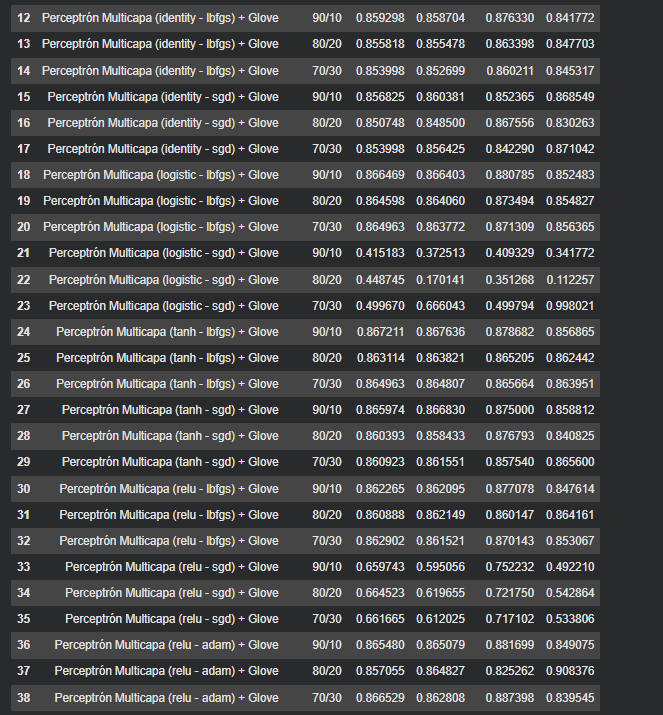

**Cortes Moreno Mauricio Hamabiel:**

Mediante patrones lingüísticos, utilizando técnicas de procesamiento de lenguaje natural, para ello, se aplicaron pasos de limpieza de texto, como la normalización, la tokenización y la eliminación de palabras vacías, posteriormente, se realizó la vectorización mediante TF-IDF y se combinó con la regresión robusta de Huber. En la práctica, el modelo permitió observar una diferencia en las predicciones, ya que fue posible distinguir la mayoría de los valores que toma cada clase y establecer un umbral para realizar la predicción binaria. Este algoritmo demostró ser una herramienta con buen rendimiento, sin embargo, presenta limitaciones, pues al no ser un clasificador puro existe un margen de error, especialmente cuando una reseña se encuentra cerca del umbral y resulta más difícil distinguir su categoría.

__Soria Martínez Jesús Armando:__

Hoy más que nunca con el auge de inteligencia artificial y los modelos generadores de lenguaje, poder identificar que fue escrito por un humano y que, por un bot, resulta cada vez más difícil, tanto para personas individuales quienes están realizando una investigación y quieren fuentes confiables, así como también para las grandes empresas de comercio electrónico que se ven afectadas por comentarios falsos hechos por bots en ciertos productos o servicios, lo que les genera pérdidas económicas. Por todo esto este proyecto tiene aplicaciones importantes para poder clasificar los comentarios de manera automática.
El uso de técnicas de PLN fue fundamental para este proyecto, así como técnicas de aprendizaje automático, se entrenaron varios modelos, por un lado, con unigramas y bigramas se entrenó la regresión robusta de Huber y Naive Bayes, y por el otro lado se implementó Glove para entrenar SVM y perceptrón multicapa con diferentes combinaciones de función de activación y optimizadores. A pesar de que la Huber no se especializa en clasificación, con las adaptaciones necesarias cuando se entrenó con TF-IDF compuesto (bigramas), fue el modelo que obtuvo la mayor precisión.

__Pacheco Molina Miguel Alejandro__

En esta práctica se aplicaron técnicas de procesamiento de lenguaje natural y un modelo de regresión robusta de Huber para clasificar reseñas de productos como originales o generadas por computadora. Se implementó un flujo completo que incluyó limpieza y normalización del texto, tokenización, eliminación de stopwords, reducción de palabras a su raíz y vectorización mediante TF-IDF.
El uso de la regresión de Huber permitió manejar valores atípicos y generar predicciones continuas, las cuales se transformaron en etiquetas binarias mediante un umbral definido visualmente a partir de la distribución de predicciones por clase, demostrando que el modelo fue capaz de diferenciar eficazmente entre reseñas reales y falsas.
La clasificación automática de reseñas tiene aplicaciones prácticas importantes, como detectar reseñas falsas que pueden afectar la reputación de productos o servicios, mejorar la confiabilidad de sistemas de recomendación y optimizar el análisis de opiniones de clientes. Además, la práctica muestra cómo un algoritmo robusto puede ser útil para manejar datos ruidosos y garantizar predicciones consistentes.
Para el siguiente parcial, se busca comparar este modelo con otros modelos especializados en clasificación, con el objetivo de evaluar si pueden lograr mayor precisión en esta tarea.


__Maldonado López Alejandro__

En definitiva, en este proyecto se aplicaron técnicas propias del procesamiento del lenguaje natural como TF-IDF y GloVe, modelos de aprendizaje máquina como lo son: Regresión de Huber, Máquina de vectores de soporte (SVM), Perceptrón Multicapa, Ingenuo de Bayes (Naive Bayes). Con el fin de clasificar reseñas de productos como generadas por una persona o generada por un humano. La limpieza y normalización del texto fueron implementados con presición con el fin de una exitosa vectorización mediante TF_IDF e implementación de GloVe. Los modelos implementados obtuvieron un buen resultado mediante ambos métodos del procesamineto de lenguaje natural teniendo así que la regresión Huber es la más destacada ya que ayudó a manejar valores atípicos para generar predicciones más precisas. Con las predicciones se desarrolla una buena evaluación para la detección de las reseñas generadas por una computadora que pueden afectar enormemente a la industria comercial y de servicios digitales.
